# Phase VI: biological function and pathway enrichment analysis 

In [68]:
import gseapy as gp
import pandas as pd
import json

In [14]:
dice_genes = pd.read_csv("../data/results/dice_genes.tsv", sep="\t", usecols=[0])
dice_genes = list(dice_genes["Unnamed: 0"])
len(dice_genes)

1332

In [16]:
type(dice_genes)

list

In [38]:
# Upload GO gmt file
go_set = "../data/enrichment/go.gmt"
kegg_set = "../data/enrichment/kegg.gmt"

In [40]:
enr_go = gp.enrich(gene_list=dice_genes, # or gene_list=glist
                 gene_sets=go_set, 
                 background=None,
                 outdir=None,
                 verbose=True)

2026-03-05 11:19:36,707 [INFO] User defined gene sets is given: ../data/enrichment/go.gmt
2026-03-05 11:19:36,856 [INFO] Run: go.gmt
2026-03-05 11:19:46,141 [INFO]   Background is not set! Use all 19591 genes in go.gmt.
2026-03-05 11:19:47,824 [INFO] Done.


In [41]:
enr_go.results.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
0,go.gmt,GO:0000014,1/12,0.563413,0.712812,1.824340,1.046701,DCLRE1C
1,go.gmt,GO:0000018,21/141,0.000435,0.004136,2.519214,19.500262,MLH1;PTPRC;TP53BP1;MBTD1;SKP2;IL7R;RAD51;SMARC...
2,go.gmt,GO:0000019,1/7,0.383307,0.597461,3.228561,3.095928,MLH1
3,go.gmt,GO:0000022,1/12,0.563413,0.712812,1.824340,1.046701,RACGAP1
4,go.gmt,GO:0000027,8/29,0.000466,0.004371,5.556332,42.629571,MDN1;MRM2;NOP2;BOP1;RPL5;RPF2;RPL11;RPL24


In [42]:
# Save the results to a new df
results_go = enr_go.results
results_go.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
0,go.gmt,GO:0000014,1/12,0.563413,0.712812,1.824340,1.046701,DCLRE1C
1,go.gmt,GO:0000018,21/141,0.000435,0.004136,2.519214,19.500262,MLH1;PTPRC;TP53BP1;MBTD1;SKP2;IL7R;RAD51;SMARC...
2,go.gmt,GO:0000019,1/7,0.383307,0.597461,3.228561,3.095928,MLH1
3,go.gmt,GO:0000022,1/12,0.563413,0.712812,1.824340,1.046701,RACGAP1
4,go.gmt,GO:0000027,8/29,0.000466,0.004371,5.556332,42.629571,MDN1;MRM2;NOP2;BOP1;RPL5;RPF2;RPL11;RPL24


In [61]:
# Filter out results with less than 0.05 adjusted p value
results_go_filt = results_go[results_go['Adjusted P-value'] < 0.05].copy()
print(f"Number of significant results: {len(results_go_filt)}")
results_go_filt.head()

Number of significant results: 1490


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
1,go.gmt,GO:0000018,21/141,0.000435,0.004136,2.519214,19.500262,MLH1;PTPRC;TP53BP1;MBTD1;SKP2;IL7R;RAD51;SMARC...
4,go.gmt,GO:0000027,8/29,0.000466,0.004371,5.556332,42.629571,MDN1;MRM2;NOP2;BOP1;RPL5;RPF2;RPL11;RPL24
5,go.gmt,GO:0000028,8/24,0.000108,0.001275,7.242051,66.170493,PRKDC;RPS27;FAU;RPS27L;RPS6;RPSA;RPS14;METTL17
9,go.gmt,GO:0000049,18/81,0.000005,0.000086,4.116810,50.292394,NSUN2;EEF1A1;PUS1;EIF2A;TRMT1;TARBP1;EIF2AK4;F...
11,go.gmt,GO:0000055,3/7,0.008459,0.045768,10.899323,52.017837,RAN;SDAD1;NUP88


### Part 2: KEGG pathway enrichment analysis

In [57]:
enr_kegg = gp.enrich(gene_list=dice_genes, 
                 gene_sets=kegg_set, 
                 background=None,
                 outdir=None,
                 verbose=True)

2026-03-05 11:37:51,325 [INFO] User defined gene sets is given: ../data/enrichment/kegg.gmt
2026-03-05 11:37:51,331 [INFO] Run: kegg.gmt
2026-03-05 11:37:51,359 [INFO]   Background is not set! Use all 8011 genes in kegg.gmt.
2026-03-05 11:37:51,432 [INFO] Done.


In [58]:
# Save the results to a new df
results_kegg = enr_kegg.results
results_kegg.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
0,kegg.gmt,hsa00010,8/68,0.385450,0.666302,1.245102,1.187009,AKR1A1;GAPDH;ACSS2;ENO3;LDHA;HK1;ALDOA;ENO2
1,kegg.gmt,hsa00020,1/30,0.959906,1.000000,0.448678,0.018360,FH
2,kegg.gmt,hsa00030,6/30,0.077106,0.200218,2.357200,6.040485,TALDO1;TKT;G6PD;PGD;PRPS1;ALDOA
3,kegg.gmt,hsa00040,1/34,0.973914,1.000000,0.394884,0.010438,AKR1A1
4,kegg.gmt,hsa00051,4/33,0.434607,0.682569,1.351022,1.125824,ALDOA;ENOSF1;TSTA3;HK1


In [60]:
# Filter out results with less than 0.05 adjusted p value
results_kegg_filt = results_kegg[results_kegg['Adjusted P-value'] < 0.05].copy()
print(f"Number of significant results: {len(results_kegg_filt)}")
results_kegg_filt.head()

Number of significant results: 87


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
14,kegg.gmt,hsa00190,31/133,6.766341e-06,1.053596e-04,2.787061,33.175926,COX7A2L;UQCRQ;ATP6V0D1;UQCR10;NDUFA6;COX7A2;ND...
71,kegg.gmt,hsa01521,16/79,5.158654e-03,2.226141e-02,2.324898,12.245424,RPS6;MAPK3;RPS6KB1;PRKCB;PLCG1;EIF4E2;GSK3B;GR...
75,kegg.gmt,hsa03008,32/108,1.251214e-08,5.523215e-07,3.871911,70.455492,RIOK2;GAR1;DKC1;RIOK1;NOL6;WDR75;WDR36;RAN;MDN...
76,kegg.gmt,hsa03010,85/158,7.938381e-44,2.452960e-41,11.377964,1129.172321,MRPS18C;MRPL24;RPS12;RPL35A;MRPL32;RPL39;RPS18...
77,kegg.gmt,hsa03013,39/180,3.142172e-06,6.472873e-05,2.543725,32.230510,DDX39B;SUMO1;EIF1;EEF1A1;NUP133;NUP160;EIF2S1;...


In [ ]:
# Upload the GO Terms and KEGG Term Mappings
kegg_map = open("../data/enrichment/kegg_mapping.json")
go_map = open(("../data/enrichment/go_mapping.json"))
kegg_terms_mapping = json.load(kegg_map)
go_term_mapping = json.load(go_map)

## Part 3: Visualization of results

In [34]:
from gseapy import barplot, dotplot

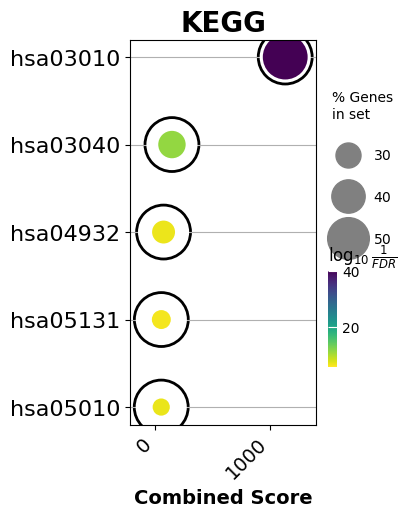

In [45]:
# categorical scatterplot
ax = dotplot(results_kegg,
              column="Adjusted P-value",
              x='Gene_set', 
              size=10,
              top_term=5,
              figsize=(3,5),
              title = "KEGG",
              xticklabels_rot=45, # rotate xtick labels
              show_ring=True, # set to False to revmove outer ring
              marker='o',
             )

In [ ]:
# categorical scatterplot
ax = dotplot(results_df_filtered,
              column="Adjusted P-value",
              x='Gene_set', 
              size=10,
              top_term=5,
              figsize=(3,5),
              title = "GO Terms",
              xticklabels_rot=45, # rotate xtick labels
              show_ring=True, # set to False to revmove outer ring
              marker='o',
             )

ValueError: Warning: No enrich terms when cutoff = 0.05